## Diffusion
- Add gaussian noise for time steps. Mean is 0, variance determined by the noise scheduler 
- Instead of adding each time step, we can add cummulative noise for lets say 25 steps at once with use of alpha and alpha hat parameter

### Forward going from X0 to Xt:

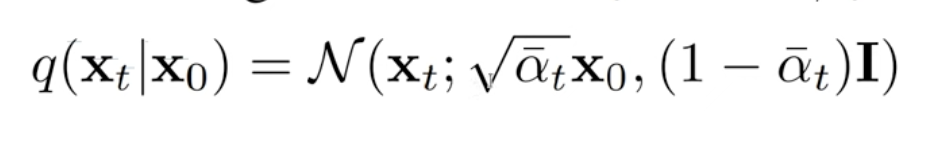


## Traing and sampling
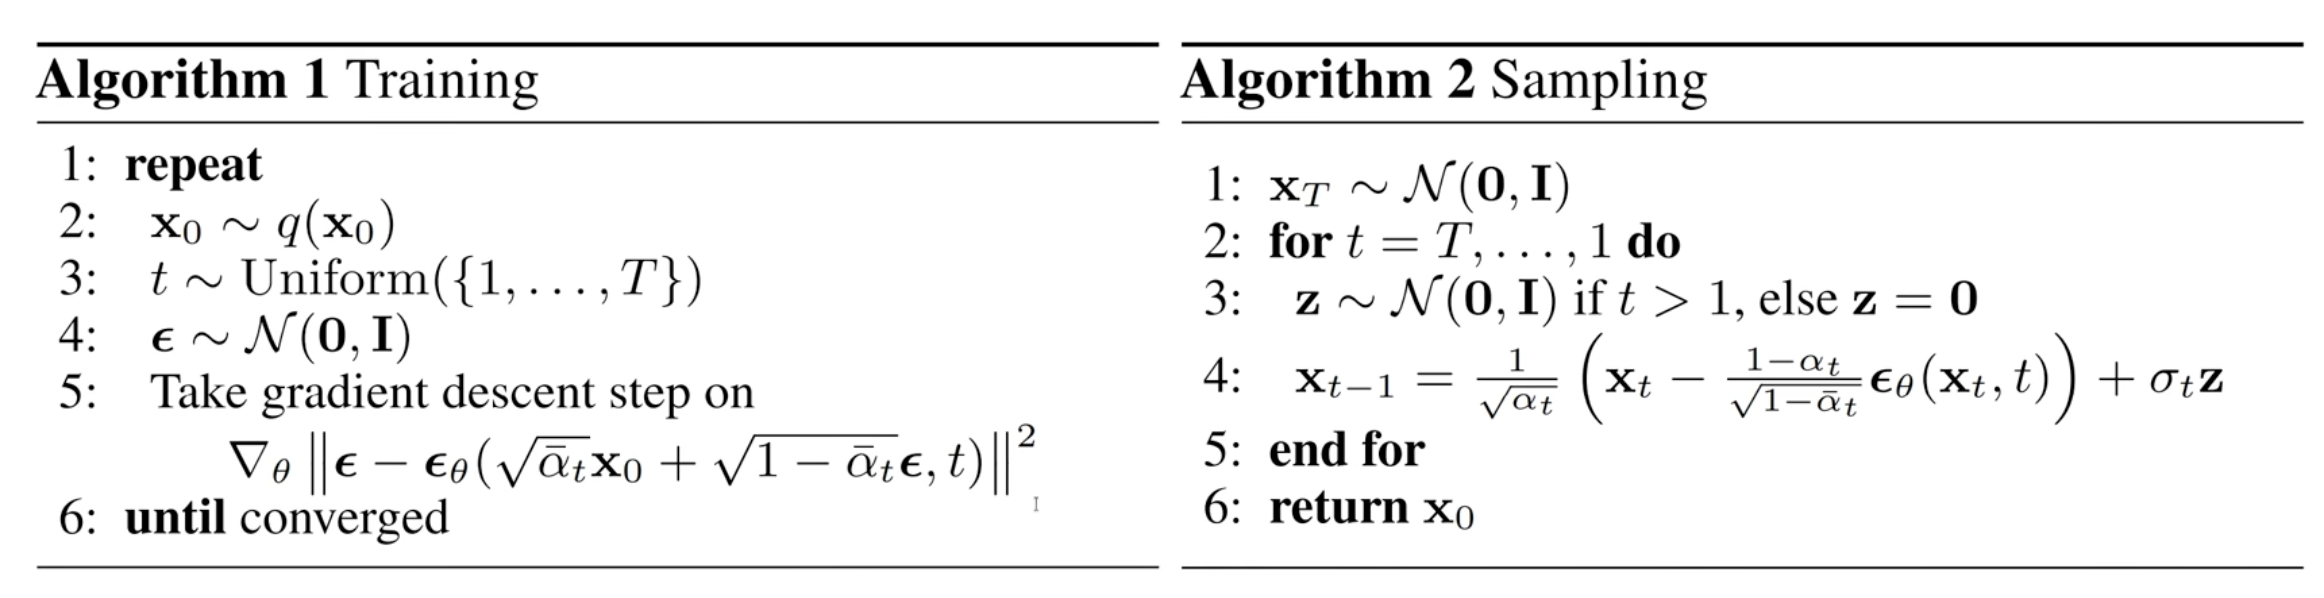


## 
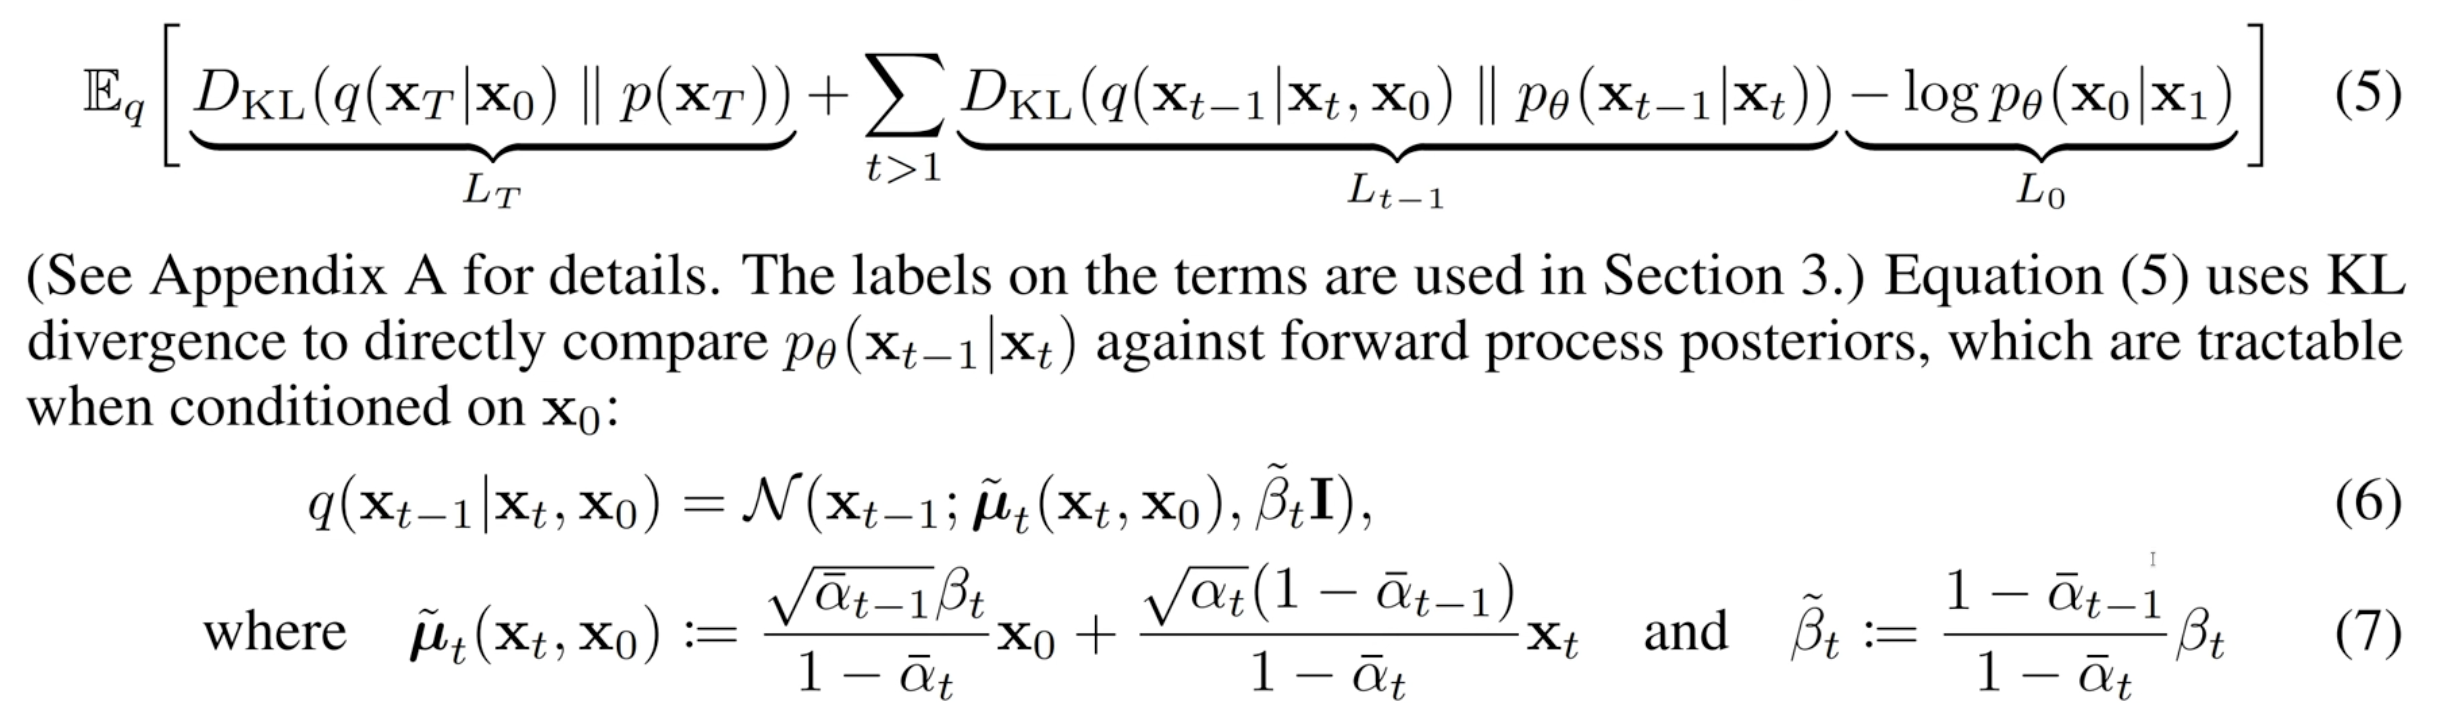

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import os
import itertools
import numpy as np

from torchvision.datasets import ImageFolder
from torchvision import transforms 
from PIL import Image
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from dataclasses import dataclass

from transformers import get_cosine_schedule_with_warmup
from torchvision import datasets, transforms

/Users/kay/miniconda/envs/diy/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Sampler

In [2]:
class Sampler:
    """
    beta -> noise we are going to add at time step t.
    alpha -> 1 - beta 
    alpha_hat -> alpha_cumprod
    sigma_t -> std. dev from variance (which is beta_t_tilda) 
    """
    def __init__(self, num_steps = 1000, beta_start = 0.0001 , beta_end = 0.01):
        self.num_steps = num_steps
        self.beta_start = beta_start
        self.beta_end = beta_end

        self.beta_schedule = self.linear_beta_scheduler()   # shape (num_steps,)

        self.alpha = 1 - self.beta_schedule
        self.alpha_cumprod = torch.cumprod(self.alpha, dim = -1)    # shape (num_steps,)

    def linear_beta_scheduler(self):
        return torch.linspace(self.beta_start, self.beta_end, self.num_steps)
    
    # addding fake dim to match input to target
    def _repeat_unsqueeze(self, input, target):
        while input.dim() < target.dim():
            input = input.unsqueeze(-1)
        return input

    def add_noise(self, data, ts):
        device = data.device

        noise = torch.randn_like(data)
        alpha_hat = self.alpha_cumprod[ts].to(device)

        mean_coeff = alpha_hat ** 0.5
        var_coeff = (1 - alpha_hat) ** 0.5
        mean_coeff = self._repeat_unsqueeze(mean_coeff, data)
        var_coeff = self._repeat_unsqueeze(var_coeff, data)
        
        # add noise to data 
        noisy_data = mean_coeff * data + var_coeff * noise

        return noisy_data, noise

    def remove_noise(self, data, ts, predicted_noise):
        device = data.device

        noise = torch.randn_like(data)

        beta_t = self.beta_schedule[ts].to(device)
        alpha_t = self.alpha[ts].to(device)
        alpha_hat_t = self.alpha_cumprod[ts].to(device)
        alpha_hat_t_prev = self.alpha_cumprod[ts-1].to(device)
        
        ## for ts 0 there is no prev alpha -> here we set to 1.0
        ts_zero_mask = ( ts ==0 )
        alpha_hat_t_prev[ts_zero_mask] = 1.0

        ## sigma_t
        variance = ( (1 - alpha_hat_t_prev) * beta_t)/ (1 - alpha_hat_t)
        variance = self._repeat_unsqueeze(variance, data) 
        sigma_t_z = variance ** 0.5 * noise

        ## noise coeff
        noise_coeff = beta_t / ( 1 - alpha_hat_t ) ** 0.5
        noise_coeff = self._repeat_unsqueeze(noise_coeff, data)

        reciproc_root_alpha_t = alpha_t ** -0.5
        reciproc_root_alpha_t = self._repeat_unsqueeze(reciproc_root_alpha_t, data)

        # denoise image by mean
        mean = reciproc_root_alpha_t * ( data - noise_coeff * predicted_noise )
        denoised_data = mean + sigma_t_z

        return denoised_data



sampler = Sampler()
img = torch.randn( 4, 3, 32, 32 )

## get rand time step of noise to add to (batch_size,) of images
rand_ts = torch.randint( low = 0, high = 1000, size = (4,) )
pred_noise = torch.randn( 4, 3, 32, 32 )
#sampler.add_noise(img, rand_ts)
sampler.remove_noise(img, rand_ts, pred_noise).shape


torch.Size([4, 3, 32, 32])

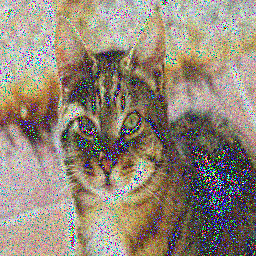

In [3]:
cat = Image.open('./cat.jpg').convert("RGB")

image2tensor_transform = transforms.Compose([
                    transforms.Resize((256, 256)), # Resize Image
                    transforms.ToTensor(), # Convert to tensor (will scale from 0 to 1)
                    transforms.Lambda(lambda t: (t*2) - 1), # Change scale to be -1 to 1
                    transforms.Lambda(lambda t: t.unsqueeze(0))
])

tensor2image_transform = transforms.Compose([
        transforms.Lambda(lambda t: t.squeeze(0)), # Remove batch dimension on
        transforms.Lambda(lambda t: (t + 1) / 2), # Scale back to 0 to 1
        transforms.Lambda(lambda t: t.permute(1, 2, 0)), # Make channels last 
        transforms.Lambda(lambda t: t * 255.), # Scale back to 0 to 255
        transforms.Lambda(lambda t: t.cpu().numpy().astype(np.uint8)), # Convert to numpy
        transforms.ToPILImage(), # Conver to PIL
    ])

noisy_data, noise = sampler.add_noise( image2tensor_transform(cat), 100 )
tensor2image_transform( sampler.remove_noise( noisy_data, 100, noise ))

## Overall process

In GAN we are asking the model to go from a noisy image to the final image in one go. 
This is too much of work for the model, instead in diffusion we are going from noise to image time step by time step.

- In forward process we add controlled stochastic(randmoly selected in this context) but known noise along with current time-step information to the image and 
- In the backward process the NN needs to predict how much noise is added to the image.
- Minimizing the ELBO turns out to be equivalent to minimizing the MSE between the predicted noise and the true noise
- so, we take the MSE of the predicted noise and actual noise as loss and minimize it.

And in backward process, we start from pure noise and time step T and we iteratively predict and remove noise 1 at a time.

### Code flow 
- We are just adding noise to the image in a pre-determined way (linear/ cosine/ etc beta schedulers ) across time steps T.
- For efficieny instead of for looping and adding by 1 time step at a time, we remodifiy the eqns to add 'K' time steps at once, this is posible because we are just adding multiple gaussian noise at a time, so combine all noise and add at once to the input. 

- For training steps T, we randomly sample batch of images and noise timestamps and add the noise.
- And the noisy images and timesteps are send to the model to output predicted added noise by the model. 
- To let the model know current time stamp (just like positional encoding in LLM), we inject sinusoidal pos embeddings in residual blocks of the NN model.


## Self Attention

In [4]:
class SelfAttention(nn.Module):
    def __init__(self, channels=32, n_head=12, attn_p=0, proj_p=0):
        super().__init__()
        self.qkv = nn.Linear(channels, channels * 3)
        self.head_dim = channels // n_head
        self.n_head = n_head
        self.attn_p = attn_p
        self.proj = nn.Linear(channels, channels)
        self.proj_p = nn.Dropout(proj_p)

    def forward(self, x ):
        B, T, C = x.shape

        # '3' is there because we have combined qkv in same matrix
        qkv = self.qkv(x).reshape(B, T, 3, self.n_head, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4) # '3'(q, k, v) x B x H x T x E
        q, k, v = qkv.unbind(0)

        x = F.scaled_dot_product_attention(q, k, v, dropout_p=self.attn_p)
        x = x.transpose(1,2).reshape(B, T, C)
        x = self.proj_p ( self.proj(x) )
        return x
    
class MLP(nn.Module):
    def __init__(self, channels=32, mlp_ratio=4, ff_drop=0):
        super().__init__()
        hddn_dim = channels * mlp_ratio
        self.proj_in = nn.Linear(channels, hddn_dim)
        self.act = nn.GELU()
        self.proj_out = nn.Linear(hddn_dim, channels)
        self.ff_drop = nn.Dropout(ff_drop)

    def forward(self, x):
        x = self.proj_in(x)
        return self.ff_drop( self.proj_out( self.act(x) ) )

class TransformerBlock(nn.Module):
    def __init__(self, channels=32, n_head=8, mlp_ratio=4, attn_p=0, proj_p=0, ff_drop=0):
        super().__init__()
        self.sa = SelfAttention(channels=channels, n_head=n_head, attn_p=attn_p, proj_p=proj_p)
        self.mlp = MLP(channels=channels, mlp_ratio=mlp_ratio, ff_drop=ff_drop)
        self.ln1 = nn.LayerNorm(channels)
        self.ln2 = nn.LayerNorm(channels)

    def forward(self, x):
        B, C, H, W = x.shape
        
        x = x.reshape(B, C, H * W).permute(0, 2, 1)
        x = x + self.sa(self.ln1(x))
        x = x + self.mlp( self.ln2(x) )

        x = x.permute(0, 2, 1).reshape(B, C, H, W)
        return x

t = TransformerBlock(channels=32)
img = torch.randn((1, 32, 128, 128))
t(img).shape

torch.Size([1, 32, 128, 128])

$$PE_{position, 2i} = sin(\frac{position}{10000^{2i/d_{model}}})$$
$$PE_{position, 2i+1} = cos(\frac{position}{10000^{2i+1/d_{model}}})$$

1. pre-compute inv_freq upto T//2 for later multipying with pos. 
2. original transformer used alternating sin, cos. here we are using 1st half sin and cos. 
3. add a mlp layer wih scaled_t_dim for expansion

In [ ]:
class SinusoidalTimesEmb(nn.Module):
    def __init__(self, t_emb_dim, scaled_t_emb_dim):
        super().__init__()
        inv_freq = 1.0 / (10000 ** (torch.arange(0, t_emb_dim, 2).float() / t_emb_dim))
        self.register_buffer("inv_freq", inv_freq)
        self.time_mlp = nn.Sequential(
            nn.Linear(t_emb_dim, scaled_t_emb_dim),
            nn.SiLU(),
            nn.Linear(scaled_t_emb_dim, scaled_t_emb_dim),
            nn.SiLU(),
        )

    def forward(self, x):
        # To get freqs for all T=t, add fake dims: ts[t, 1] * freq[1, T//2]
        ts_freq = x.unsqueeze(1) * self.inv_freq.unsqueeze(0)
        embs = torch.cat( [torch.sin(ts_freq), torch.cos(ts_freq)], dim=-1 )
        embs = self.time_mlp(embs)
        return embs


pos = SinusoidalTimesEmb(128, 256)
x = torch.tensor([1,2,3])
pos(x).shape

torch.Size([3, 256])

> Why pre normalization? 

>    we use “pre-activation” order in modern architectures like: ResNet v2, UNet used in diffusion models (DDPM, Stable Diffusion), Many transformer-style and modern CNN designs

>    because:
>- Normalization and activation happen before the convolution, so the convolution sees normalized, nonlinearly transformed inputs.
>- This improves gradient flow and training stability, especially in deep networks.
>- The residual connections (in ResBlocks) behave better because the conv operates on normalized activations.

### Residual block

1. we need to inject time info from SinPosEmb to UNET to know abt current ts.
2. Input H and W we are not changing, channels may change. 
    - 1st set of conv -> add time info -> 2nd conv -> add res conn/ input x 
3. every single block in UNet we are going to do this

In [6]:
class ResidualBlock(nn.Module):
    """
    H and W are same for input and output, channels sometimes changes
    """
    def __init__(self, in_channels, out_channels, norm_groups, t_emb_dim):
        super().__init__()

        ## convert any time's Tensor dim to out_channel size, so we can add with the image
        self.time_expand = nn.Linear(t_emb_dim, out_channels)

        ## convs
        self.norm1 = nn.GroupNorm(norm_groups, num_channels=in_channels)
        self.conv1 = nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size=3, padding='same')

        self.norm2 = nn.GroupNorm(norm_groups, num_channels=out_channels)
        self.conv2 = nn.Conv2d(in_channels=out_channels, out_channels=out_channels, kernel_size=3, padding='same')

        ## resize input to have same channel as output so that we can add both, for res connection
        self.resize_conv = nn.Conv2d(in_channels, out_channels, kernel_size=1) if in_channels != out_channels else nn.Identity()


    def forward(self, x, t_embs):
        res_conn = x
        t_embs = self.time_expand(t_embs)

        x = self.conv1( F.silu(self.norm1(x) ) )
        x = x + t_embs[:, :, None, None] ## add X + time info
        x = self.conv2( F.silu(self.norm2(x) ) )

        x = x + self.resize_conv(res_conn) ## resize input to match ouput channels
        return x

x = torch.randn((4, 64, 128, 128))
t_embs = torch.randn((4, 256)) # B x T; T should be same as 
rb = ResidualBlock(64, 128, 16, 256)
rb(x, t_embs).shape

torch.Size([4, 128, 128, 128])

### Upsampling

- downsampling is simple we can do by stride. 
- upsampling, we have 2 option:
    - transpose conv
    - upsampling followed by std conv
- up sampl is preferred for img generation since 1st one leads some tiling, checkerboard artifact pattern 


In [7]:
class Upsample(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.upsample = nn.Sequential(
            nn.Upsample(scale_factor=2),
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding='same')
        )
    def forward(self, x):
        B, C, H, W = x.shape
        x = self.upsample(x)
        # because we will always downsample by 2 and upsample by 2
        assert x.shape == (B, C, H * 2, W * 2)
        return x
img = torch.randn(4, 128, 128, 128)
us = Upsample(128, 128)
us(img).shape

torch.Size([4, 128, 256, 256])

In [8]:
class UNET(nn.Module):
    def __init__(self, 
                 in_channels = 3,
                 start_dim = 64,
                 dim_mults = (1, 2, 4),
                 res_block_per_group = 1, 
                 num_group_norms = 16,
                 t_emb_dim = 128,
                 ):
        super().__init__()

        self.input_channels = in_channels
        channels_list = [i * start_dim for i in dim_mults]
        
        """
        image -> n_res_block x (same dim handling) -> downsample (H, W) -> attn -> channel inc
        1. (C x H x W) -> (C x H//2 x W//2) -> attn -> (2*C x H//2 x W//2)
        2. (2*C x H//2 x W//2) -> (2*C x H//4 x W//4) -> attn -> (4*C x H//4 x W//4)
        ...
        ...
        """
        self.encoder_config = []
        for idx, d in enumerate(channels_list):
            for n in range(res_block_per_group):
                self.encoder_config.append( ( ((d, d), "residual") ) )
            
            self.encoder_config.append( ((d, d), "downsample") ) # img size will become half with stride = 2
            self.encoder_config.append( ((d,), "attention") )

            if idx < len(channels_list) - 1:
                self.encoder_config.append( ((d, channels_list[idx+1]), "residual") )

        self.bottleneck_config = []
        for _ in range(res_block_per_group):
            self.bottleneck_config.append( ((d,d), "residual") )
        
        ## reverse the encoder
        out_dim = channels_list[-1]
        revered_encoder_config = list(reversed(self.encoder_config))
        self.decoder_config = []
        
        """
        we want to mirror enc add output from enc to dec via res conn, hence input channels will increase.
        go through in reverse order and:
        1. if residual
          - concat res conn on top of the output channels
        2. if downsample
          - concat res conn on top of the output channels
          - upsample
        3. attention
          - just do attention
        """
        for idx, (dim, blk_type) in enumerate(revered_encoder_config):
            if blk_type != "attention":
                enc_in_channels, enc_out_channels = dim[0], dim[-1]
                # on the output add mirrored encoder's output channels and conv to mirrored input size
                self.decoder_config.append( ( (out_dim + enc_out_channels, enc_in_channels ), "residual" ) )

                if blk_type == "downsample":
                    self.decoder_config.append( ( (enc_in_channels, enc_in_channels), "upsample" ) )
                
                out_dim = enc_in_channels
            else:
                enc_in_channels = dim
                self.decoder_config.append( ((dim[0], ), "attention") )
        self.decoder_config.append(((channels_list[0]*2, channels_list[0]), "residual"))
        
        """
        print("## encoder::")
        for _ in self.encoder_config:
            print(_)

        print("## self.bottleneck_config::")
        for _ in self.bottleneck_config:
            print(_)

        print("## decoder::")
        for _ in self.decoder_config:
            print(_)
        """
        
        ## defining model 
        # convert img channels to 1st block's channel for input
        self.proj_in = nn.Conv2d(in_channels=self.input_channels, out_channels=channels_list[0], kernel_size=3, padding="same")

        # u-net blocks
        build_args = {"num_group_norms": num_group_norms, "t_emb_dim": t_emb_dim}
        self.encoder = self._build_block(self.encoder_config, args=build_args)
        self.bottleneck = self._build_block(self.bottleneck_config, args=build_args)
        self.decoder = self._build_block(self.decoder_config, args=build_args)

        # out proj 
        self.proj_out = nn.Conv2d(channels_list[0], self.input_channels, kernel_size=3, padding="same")

        
    def _build_block(self, config, args={}):
        block = nn.ModuleList()
        for (dim, blk_type) in config:
            in_ch, out_ch = dim[0], dim[-1] 
            if blk_type == "residual":
                block.append( ResidualBlock(in_channels=in_ch, out_channels=out_ch,
                                            norm_groups=args["num_group_norms"], t_emb_dim=args["t_emb_dim"]) )
            elif blk_type == "attention":
                block.append(
                    TransformerBlock(in_ch)
                )
            elif blk_type == "downsample":
                block.append( 
                    nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=2, padding=1)
                )
            elif blk_type == "upsample":
                block.append(
                    Upsample(in_ch, out_ch)
                )
            else:
                raise Exception(f"Unknown blk type {blk_type}")
        return block

    def forward(self, x, time_embeddings):
        residuals = []
        x = self.proj_in(x)
        residuals.append(x)

        for blk in self.encoder:
            if isinstance(blk, ResidualBlock):
                x = blk(x, time_embeddings)
                residuals.append(x)
            elif isinstance(blk, TransformerBlock):
                x = blk(x)
                residuals.append(x)
            elif isinstance(blk, nn.Conv2d):
                x = blk(x)
        
        for blk in self.bottleneck:
            x = blk(x, time_embeddings)

        for blk in self.decoder:
            if isinstance(blk, ResidualBlock):
                residual_tensor = residuals.pop()
                x  = torch.cat([x, residual_tensor], axis=1)
                x = blk(x, time_embeddings)
            else:
                x = blk(x)
        
        x = self.proj_out(x)
        return x


unet = UNET()

rand_image = torch.randn(4, 3, 256, 256)
rand_time_embeddings = torch.randn(4, 128)
unet(rand_image, rand_time_embeddings).shape

torch.Size([4, 3, 256, 256])

## Diffusion

In [9]:
class Diffusion(nn.Module):
    def __init__(self, 
                 in_channels = 3,
                 start_dim = 64,
                 dim_mults = (1, 2, 4),
                 res_block_per_group = 1, 
                 num_group_norms = 16,
                 t_emb_dim = 128,
                 t_emb_ratio = 2,
                 ):
        super().__init__()

        self.in_channels = in_channels
        self.start_dim = start_dim
        self.dim_mults = dim_mults
        self.res_block_per_group = res_block_per_group
        self.num_group_norms = num_group_norms
        self.t_emb_dim = t_emb_dim
        self.t_emb_ratio = t_emb_ratio

        scaled_t_emb_dim = self.t_emb_dim * self.t_emb_ratio

        self.time_embs = SinusoidalTimesEmb(self.t_emb_dim, scaled_t_emb_dim = scaled_t_emb_dim )
        self.unet = UNET(
                 in_channels = self.in_channels,
                 start_dim = self.start_dim,
                 dim_mults = self.dim_mults,
                 res_block_per_group = self.res_block_per_group,
                 num_group_norms = self.num_group_norms,
                 t_emb_dim = scaled_t_emb_dim
        )

    def forward(self, noisy_img, time_steps):

        # get time embs for given ts and pass to unet
        t_embs = self.time_embs(time_steps)

        pred_noise = self.unet(noisy_img, t_embs)

        return pred_noise

df = Diffusion()

rand_image = torch.randn(4, 3, 256, 256)
rand_time_embeddings = torch.randint(0, 128, (4,))
df(rand_image, rand_time_embeddings).shape

torch.Size([4, 3, 256, 256])

## Train

In [10]:
@torch.no_grad()
def sample_plot_image(step_idx, 
                      total_timesteps, 
                      sampler, 
                      image_size,
                      num_channels,
                      plot_freq, 
                      model,
                      num_gens,
                      path_to_generated_dir,
                      device,
                      save_image=True):

    ### Conver Tensor back to Image (From Huggingface Annotated Diffusion) ###
    tensor2image_transform = transforms.Compose([
        transforms.Lambda(lambda t: t.squeeze(0)),
        transforms.Lambda(lambda t: (t + 1) / 2),
        transforms.Lambda(lambda t: t.permute(1, 2, 0)),
        transforms.Lambda(lambda t: t * 255.),
        transforms.Lambda(lambda t: t.cpu().numpy().astype(np.uint8)),
        transforms.ToPILImage(),
    ])

    images = torch.randn((num_gens, num_channels, image_size, image_size))
    num_images_per_gen = (total_timesteps // plot_freq)

    images_to_vis = [[] for _ in range(num_gens)]
    for t in np.arange(total_timesteps)[::-1]:
        ts = torch.full((num_gens, ), t)
        noise_pred = model(images.to(device), ts.to(device)).detach().cpu()
        images = sampler.remove_noise(images, ts, noise_pred)
        if t % plot_freq == 0:
            for idx, image in enumerate(images):
                images_to_vis[idx].append(tensor2image_transform(image))


    images_to_vis = list(itertools.chain(*images_to_vis))

    fig, axes = plt.subplots(nrows=num_gens, ncols=num_images_per_gen, figsize=(num_images_per_gen, num_gens))
    plt.tight_layout()
    for ax, image in zip(axes.ravel(), images_to_vis):
        ax.imshow(image)
        ax.axis("off")
    fig.subplots_adjust(wspace=0.05, hspace=0.05)
    if save_image:
        plt.savefig(os.path.join(path_to_generated_dir, f"step_{step_idx}.png"))
    plt.show()
    plt.close()

In [ ]:
def scale_to_minus1_1(t):
    return (t * 2) - 1

def train(image_size=64, 
          eval_interval=5000,
          total_timesteps=500, 
          plot_freq_interval=50, 
          num_generations=5, 
          num_training_steps=50000, 
          num_input_channels=3, 
          batch_size=64,
          path_to_generated="generated"):

    torch.backends.cudnn.benchmark = True

    device = "cuda" if torch.cuda.is_available() else "cpu"
    ddpm_sampler = Sampler(num_steps=total_timesteps)
    loss_fn = nn.MSELoss()
    current_step = 0
    progress_bar = tqdm(range(num_training_steps))

    # Convert img to [-1, 1] tensor 
    img2tensor = transforms.Compose([
                    transforms.Resize((image_size, image_size)),
                    transforms.RandomHorizontalFlip(),
                    transforms.ToTensor(), 
                    transforms.Lambda(scale_to_minus1_1)
                ])
    dataset = ImageFolder("../data/anime_faces/", transform=img2tensor) # https://www.kaggle.com/datasets/splcher/animefacedataset
    trainloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)

    model = Diffusion(in_channels=num_input_channels).to(device)

    model_parameters = filter(lambda p: p.requires_grad, model.parameters())
    params = sum([np.prod(p.size()) for p in model_parameters])
    print("Number of Parameters:", params)

    optimizer = torch.optim.AdamW(params=model.parameters(), lr=0.0005)
    scheduler = get_cosine_schedule_with_warmup(optimizer=optimizer,
                                                num_warmup_steps=2500, 
                                                num_training_steps=num_training_steps)

    train = True
    while train:
        training_losses = []
        for images, _ in trainloader:
            batch_size = images.shape[0]
        
            timesteps = torch.randint(0,total_timesteps,(batch_size,)) # random sample T
            noisy_images, noise = ddpm_sampler.add_noise(images, timesteps) # add noise for T=t
            noise_pred = model(noisy_images.to(device), timesteps.to(device)) # model's noise pred
            loss = loss_fn(noise_pred, noise.to(device))

            training_losses.append(loss.cpu().item())
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            optimizer.step()
            scheduler.step()
            optimizer.zero_grad(set_to_none=True)

            progress_bar.update(1)
            current_step += 1

            if (current_step % eval_interval == 0):
                loss_mean = np.mean(training_losses)
                print("Training loss:", loss_mean)
                print("Current learning rate:", optimizer.param_groups[-1]["lr"])

                training_losses = []
                print("Saving Image Generation")
                sample_plot_image(step_idx=current_step, 
                                  total_timesteps=total_timesteps, 
                                  sampler=ddpm_sampler, 
                                  image_size=image_size,
                                  num_channels=num_input_channels,
                                  plot_freq=plot_freq_interval, 
                                  model=model,
                                  num_gens=num_generations,
                                  path_to_generated_dir=path_to_generated,
                                  device=device)
                
            if current_step >= num_training_steps:
                print("Training Completed")
                train = False
                break
train()


Number of Parameters: 14306947


torch.Size([64, 256])


torch.Size([64, 256])


torch.Size([64, 256])


KeyboardInterrupt: 

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50000/50000 [1:26:18<00:00, 10.26it/s]Training loss: 0.041890810777743655

In [11]:
model = Diffusion(in_channels=3)
device = "cuda" if torch.cuda.is_available() else "cpu"
trained_checkpoint = torch.load('generated/diffusion_checkpoint_step_50000.pt', map_location=device)
model.load_state_dict(trained_checkpoint['model_state_dict'])
model

Diffusion(
  (time_embs): SinusoidalTimesEmb(
    (time_mlp): Sequential(
      (0): Linear(in_features=128, out_features=256, bias=True)
      (1): SiLU()
      (2): Linear(in_features=256, out_features=256, bias=True)
      (3): SiLU()
    )
  )
  (unet): UNET(
    (proj_in): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (encoder): ModuleList(
      (0): ResidualBlock(
        (time_expand): Linear(in_features=256, out_features=64, bias=True)
        (norm1): GroupNorm(16, 64, eps=1e-05, affine=True)
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
        (norm2): GroupNorm(16, 64, eps=1e-05, affine=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
        (resize_conv): Identity()
      )
      (1): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (2): TransformerBlock(
        (sa): SelfAttention(
          (qkv): Linear(in_features=64, out_features=192, bias=True)
    

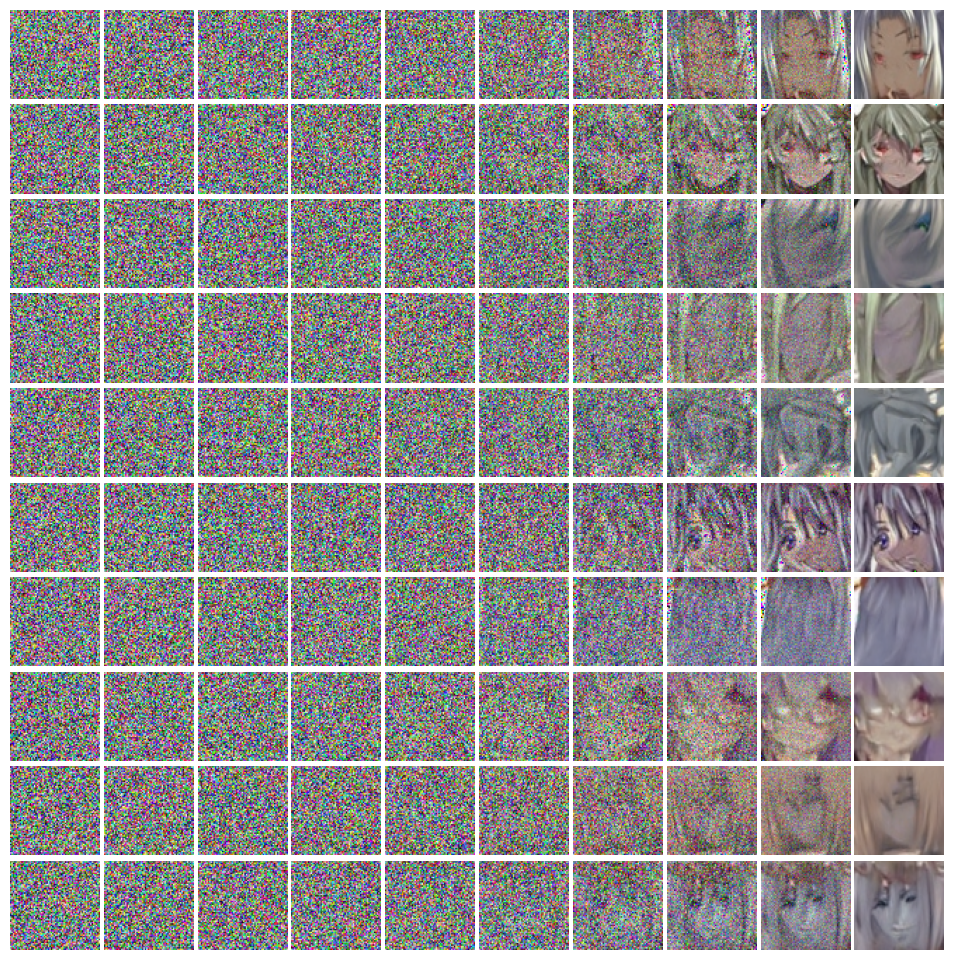

In [13]:
total_timesteps=500
ddpm_sampler = Sampler(num_steps=total_timesteps)
sample_plot_image(step_idx=50000, 
                total_timesteps=500, 
                sampler=ddpm_sampler, 
                image_size=64,
                num_channels=3,
                plot_freq=50, 
                model=model,
                num_gens=10,
                path_to_generated_dir="",
                device=device)

#### Thoughts

- Can diffusion model overfit?